# Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression
print(LogisticRegression)

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [35]:
%run ./preprocessing.ipynb

In [36]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# identify column types from preprocessed split
numeric_features = numeric_cols
categorical_features = categorical_cols

# preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# baseline logistic regression pipeline
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000
    ))
])

# hyperparameter tuning
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__solver": ["lbfgs"]
}

grid_search = GridSearchCV(
    log_reg_pipeline,
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train_raw)

best_model = grid_search.best_estimator_

val_preds = best_model.predict(X_val)
print("Best parameters:", grid_search.best_params_)
print("Validation Accuracy:", accuracy_score(y_val_raw, val_preds))

test_preds = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test_raw, test_preds))
print("Baseline Macro F1:", f1_score(y_test_raw, test_preds, average="macro"))

print("\nClassification Report:\n")
print(classification_report(y_test_raw, test_preds))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_raw, test_preds))

Best parameters: {'classifier__C': 0.01, 'classifier__solver': 'lbfgs'}
Validation Accuracy: 0.5767352896763477
Test Accuracy: 0.5766055969398027
Baseline Macro F1: 0.3779722678638941

Classification Report:

              precision    recall  f1-score   support

         <30       0.44      0.02      0.04      2263
         >30       0.52      0.31      0.39      7100
          NO       0.59      0.88      0.71     10505

    accuracy                           0.58     19868
   macro avg       0.52      0.40      0.38     19868
weighted avg       0.55      0.58      0.52     19868


Confusion Matrix:

[[  47  736 1480]
 [  42 2181 4877]
 [  19 1258 9228]]


In [38]:
balanced_log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=grid_search.best_params_["classifier__C"],
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced"
    ))
])

balanced_log_reg_pipeline.fit(X_train, y_train_raw)

balanced_val_preds = balanced_log_reg_pipeline.predict(X_val)
balanced_test_preds = balanced_log_reg_pipeline.predict(X_test)

print("Balanced Validation Accuracy:", accuracy_score(y_val_raw, balanced_val_preds))
print("Balanced Test Accuracy:", accuracy_score(y_test_raw, balanced_test_preds))
print("Balanced Macro F1:", f1_score(y_test_raw, balanced_test_preds, average="macro"))

print("\nBalanced Classification Report:\n")
print(classification_report(y_test_raw, balanced_test_preds))

print("\nBalanced Confusion Matrix:\n")
print(confusion_matrix(y_test_raw, balanced_test_preds))

Balanced Validation Accuracy: 0.5000755020888912
Balanced Test Accuracy: 0.49939601369035636
Balanced Macro F1: 0.43825188371000373

Balanced Classification Report:

              precision    recall  f1-score   support

         <30       0.20      0.41      0.27      2263
         >30       0.48      0.37      0.42      7100
          NO       0.66      0.61      0.63     10505

    accuracy                           0.50     19868
   macro avg       0.44      0.46      0.44     19868
weighted avg       0.54      0.50      0.51     19868


Balanced Confusion Matrix:

[[ 932  629  702]
 [1868 2613 2619]
 [1898 2230 6377]]


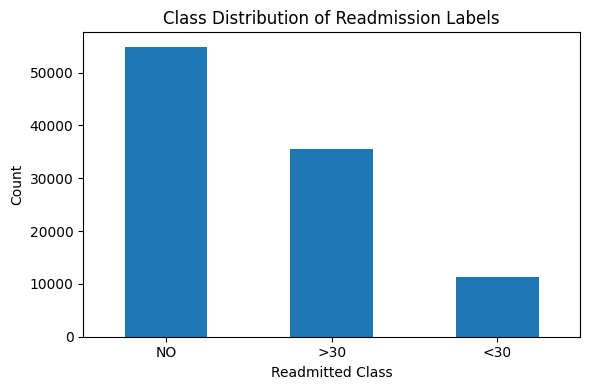

In [39]:
import matplotlib.pyplot as plt

class_counts = y.value_counts()

plt.figure(figsize=(6,4))
class_counts.plot(kind="bar")
plt.title("Class Distribution of Readmission Labels")
plt.xlabel("Readmitted Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

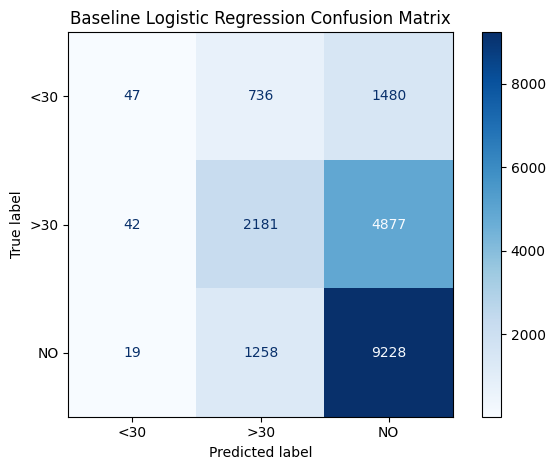

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

labels = ["<30", ">30", "NO"]

cm_baseline = confusion_matrix(y_test_raw, test_preds, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=labels)

disp.plot(cmap="Blues", values_format="d")
plt.title("Baseline Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

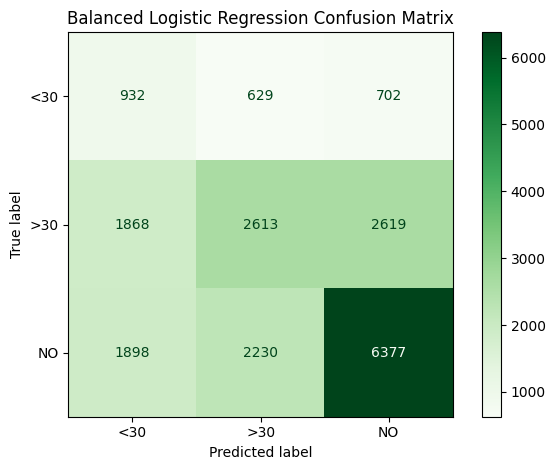

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

labels = ["<30", ">30", "NO"]

cm_balanced = confusion_matrix(y_test_raw, balanced_test_preds, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_balanced, display_labels=labels)

disp.plot(cmap="Greens", values_format="d")
plt.title("Balanced Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

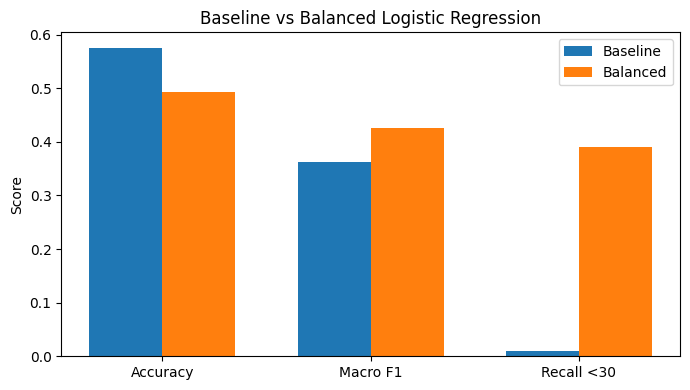

In [45]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Macro F1", "Recall <30"]
baseline_vals = [0.5754, 0.3616, 0.01]
balanced_vals = [0.4929, 0.4254, 0.39]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(7,4))
plt.bar([i - width/2 for i in x], baseline_vals, width=width, label="Baseline")
plt.bar([i + width/2 for i in x], balanced_vals, width=width, label="Balanced")
plt.xticks(list(x), metrics)
plt.ylabel("Score")
plt.title("Baseline vs Balanced Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()